In [50]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\bhavi\Downloads\New folder\kddcup99.csv",
    header=None,
    low_memory=False
)


In [51]:
print(df.shape)

(494021, 42)


Define columns names

In [52]:
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files",
    "num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate","label"
]

df.columns = columns

Remove duplicates

In [53]:
df = df.drop_duplicates()
print(df.shape)

(145586, 42)


In [54]:
#Keep Only DoS Attacks + Normal
dos_attacks = [
    'back.', 'land.', 'neptune.', 'pod.', 'smurf.', 'teardrop.'
]

df = df[df['label'].isin(['normal'] + dos_attacks)]

In [32]:
#convert label binary
df['label'] = df['label'].apply(lambda x: 0 if x == 'normal' else 1)

In [55]:
df['label'] = df['label'].apply(lambda x: 0 if 'normal' in x else 1)

In [66]:
print(df['label'].value_counts())

label
0    87831
Name: count, dtype: int64


In [56]:
#encode categorical features
df = pd.get_dummies(df, columns=["protocol_type", "service", "flag"])

In [58]:
#split feature and target 
X = df.drop("label", axis=1)
y = df["label"]

In [59]:
#train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [61]:
#random forest classifier
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1   # faster
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [62]:
y_pred = model.predict(X_test) #prediction

In [63]:
#evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17567

    accuracy                           1.00     17567
   macro avg       1.00      1.00      1.00     17567
weighted avg       1.00      1.00      1.00     17567

[[17567]]


C:\Users\bhavi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [64]:
#feature importance
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

importance.head(10)

,Feature,Importance
0,duration,0.0
56,service_red_i,0.0
54,service_pop_3,0.0
53,service_other,0.0
52,service_ntp_u,0.0
51,service_http,0.0
50,service_ftp_data,0.0
49,service_ftp,0.0
48,service_finger,0.0
47,service_ecr_i,0.0


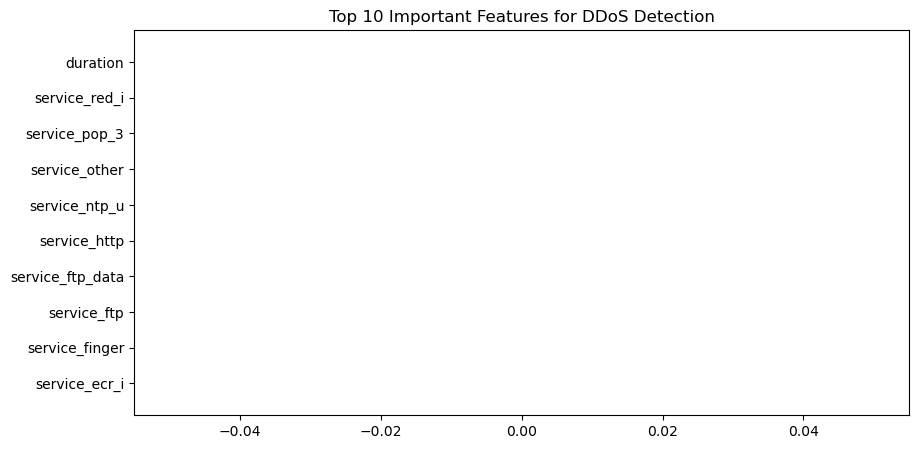

In [65]:
#visualization
import matplotlib.pyplot as plt

top10 = importance.head(10)

plt.figure(figsize=(10,5))
plt.barh(top10['Feature'], top10['Importance'])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features for DDoS Detection")
plt.show()

In [44]:
print(y.value_counts())

label
1    87831
Name: count, dtype: int64


In [71]:
import pandas as pd

# Load dataset
df = pd.read_csv(
    r"C:\Users\bhavi\Downloads\New folder\kddcup99.csv",
    header=None,
    low_memory=False
)

# Assign column names
df.columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label"
]

# ❌ DO NOT FILTER ANYTHING HERE

# Convert label (safe method)
df['label'] = df['label'].apply(lambda x: 0 if 'normal' in x else 1)

# ✅ Check labels
print(df['label'].value_counts())

label
1    396744
0     97277
Name: count, dtype: int64


In [72]:
df = pd.get_dummies(df, columns=["protocol_type", "service", "flag"])

In [73]:
X = df.drop("label", axis=1)
y = df["label"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Label distribution:
 label
1    396743
0     97277
Name: count, dtype: int64
Accuracy: 0.999706489615805

Top Features:
 count                          0.144118
dst_bytes                      0.098820
protocol_type_icmp             0.082889
service_ecr_i                  0.068492
logged_in                      0.062346
srv_count                      0.061971
src_bytes                      0.055754
service_http                   0.048649
dst_host_same_src_port_rate    0.042459
dst_host_srv_diff_host_rate    0.039647
dtype: float64
Duplicates: 348436
[[19359     7]
 [   22 79416]]
[0.98529412 0.99993927 0.99994939 0.99974697 0.99971661]
Mean accuracy: 0.9969292741184568
Duplicates: 0
[[19359     7]
 [   22 79416]]
[0.98529412 0.99993927 0.99994939 0.99974697 0.99971661]
Mean accuracy: 0.9969292741184568
Accuracy: 0.999706489615805
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19366
           1       1.00      1.00      1.00     79

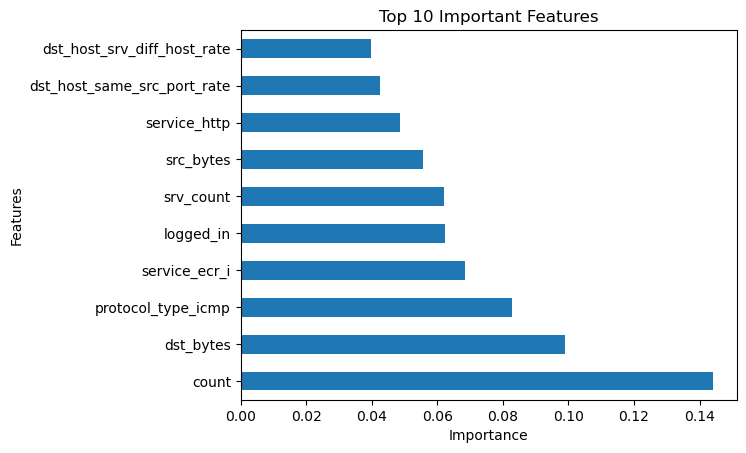

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. Load Dataset
# =========================
df = pd.read_csv(
    r"C:\Users\bhavi\Downloads\New folder\kddcup99.csv",
    header=None,
    low_memory=False
)

# =========================
# 2. Assign Column Names
# =========================
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label"
]

df.columns = columns

# =========================
# 3. Clean Data (IMPORTANT FIX)
# =========================
# Remove accidental header row if present
df = df[df['duration'] != 'duration']

# Reset index
df = df.reset_index(drop=True)

# =========================
# 4. Convert Label (Binary)
# =========================
df['label'] = df['label'].apply(lambda x: 0 if 'normal' in str(x) else 1)

# Check labels
print("Label distribution:\n", df['label'].value_counts())

# =========================
# 5. Encode Categorical Features
# =========================
df = pd.get_dummies(df, columns=["protocol_type", "service", "flag"])

# =========================
# 6. Prepare Data
# =========================
X = df.drop("label", axis=1)
y = df["label"]

# =========================
# 7. Train-Test Split
# =========================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 8. Train Model
# =========================
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

# =========================
# 9. Evaluate Model
# =========================
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

# =========================
# 10. Feature Importance
# =========================
importances = model.feature_importances_

feature_importance = pd.Series(importances, index=X.columns)
top_features = feature_importance.sort_values(ascending=False).head(10)

print("\nTop Features:\n", top_features)
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))
from sklearn.model_selection import cross_val_score


scores = cross_val_score(model, X, y, cv=5)
print(scores)
print("Mean accuracy:", scores.mean())
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)
print(scores)
print("Mean accuracy:", scores.mean())

#evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# =========================
# 11. Plot Graph
# =========================
top_features.plot(kind='barh')
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

In [2]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[19359     7]
 [   22 79416]]


In [3]:
class_weight="balanced"

In [4]:
RandomForestClassifier(class_weight="balanced")

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [5]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

In [6]:
from sklearn.preprocessing import StandardScaler

In [7]:
from sklearn.feature_selection import SelectKBest, f_classif

In [9]:
y_prob = model.predict_proba(X_test)[:,1]
y_pred = (y_prob > 0.4).astype(int)

In [10]:
from sklearn.model_selection import cross_val_score

In [11]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 6.4 MB/s eta 0:00:16
   - -------------------------------------- 2.9/101.7 MB 8.9 MB/s eta 0:00:12
   -- ------------------------------------- 5.5/101.7 MB 10.0 MB/s eta 0:00:10
   -- ------------------------------------- 7.3/101.7 MB 9.9 MB/s eta 0:00:10
   --- ------------------------------------ 9.7/101.7 MB 10.2 MB/s eta 0:00:10
   ---- ----------------------------------- 12.3/101.7 MB 10.5 MB/s eta 0:00:09
   ----- ---------------------------------- 14.4/101.7 MB 10.5 MB/s eta 0:00:09
   ------ --------------------------------- 16.8/101.7 MB 10.5 MB/s eta 0:00:09
   ------- -------------------------------- 18.9/101.7 MB 10.4 MB/s eta 0:00:08
   -------- ------------------------------- 21.0/101.7 MB 10.4 MB/s eta 0:00:08
   --------- ------------------------------ 23.1/101.7 MB 10.3 MB/s eta 0:00:08
   --------- ------------------------------ 25.2/101.7 MB

In [ ]:
conda install -c conda-forge xgboost

In [ ]:
from xgboost import XGBClassifier
model = XGBClassifier()

In [ ]:
import sys
print(sys.executable)